In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import pickle
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe, matplotlib_to_plotly, interactive_colored_mapbox

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_ID = 'EL30'
TEST_YEAR = '2022'
TEST_MONTH = '8'
NUTS2_EL = 'αττικης'

In [3]:
trained_model = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Trained_Model.pkl', 'rb'))
scaler = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Scaler.pkl', 'rb'))
imputer = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Imputer.pkl', 'rb'))
feature_names = pickle.load(open(f'../../../data/{NUTS0}_NUTS3_2010-2023_WNV_Feature_List.pkl', 'rb'))

In [4]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Greece/data'

test_file = f'{base_folder}/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_OP_2010_2023.csv'
data_test = read_data(test_file)
data_test.reset_index(drop = True, inplace = True)
print(data_test.shape)

(1176, 112)


In [5]:
data_test.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL301,2010,1,23.825080,38.055971,0.249640,0.154335,-0.051484,-0.154335,0.254681,0.151875,-0.063238,-0.151875,0.038201,0.028667,0.031282,0.028667,13.766817,10.845785,11.665333,17.146430,17.146430,8.722301,5.512796,4.611190,6.437312,6.437312,11.244559,8.179290,8.138262,11.791871,11.791871,4.383333,17.155333,7.347749,23.337556,32.042954,227.170870,1236.463865,31.000000,1.000000,19.000000,19.166667,42.592593,920.721061,45.0,0.0,45.0,8.333333,30.666667,30.666667,8.333333,1230.0,227.0,9.0,72.351252,546.0,54.0,54.0,546.0,22,9,20,13,13,10,8,9,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.00000,21.863192,45632.0,201617.0,45952.0,293201.0,43321.0,220852.0,58521.0,322694.0,19823.63,881.0,2990.0,0
1,EL302,2010,1,23.686502,38.024894,0.121799,0.075708,-0.046494,-0.075708,0.143216,0.084564,-0.051676,-0.084564,0.056306,0.024884,0.032559,0.024884,14.818000,11.446903,11.409714,18.024968,18.024968,10.888194,7.663290,6.765429,8.584452,8.584452,12.853097,9.555097,9.087571,13.304710,13.304710,7.018000,18.394000,7.394180,19.997378,29.097844,228.684803,1221.439881,31.000000,1.000000,20.791667,18.916667,42.992424,928.453830,46.0,2.0,44.0,9.833333,33.000000,33.000000,9.833333,1216.0,229.0,10.0,72.746381,538.0,55.0,55.0,538.0,1,9,1,13,13,10,8,9,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.0,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.00000,2.978368,39132.0,180473.0,33120.0,252725.0,36806.0,177964.0,43801.0,258571.0,7725.12,2236.0,2561.0,0
2,EL303,2010,1,23.757527,37.973503,0.146768,0.161544,0.060901,-0.161544,0.161503,0.148007,0.031014,-0.148007,0.061136,0.049947,0.054355,0.049947,14.646194,11.370194,11.357643,17.054194,17.054194,10.155161,7.744364,5.893857,7.908516,7.908516,12.400677,9.557279,8.625750,12.481355,12.481355,5.418000,18.374000,6.734685,29.146720,36.374201,208.524210,1181.441722,31.000000,1.000000,19.875000,18.250000,43.452381,879.081390,44.0,2.0,42.0,9.833333,31.333333,31.333333,9.833333,1175.0,208.0,5.0,73.228177,521.0,47.0,47.0,521.0,1,9,1,13,13,10,8,9,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,5491.611975,467.065216,3,162.183002,68.02

In [6]:
data_test = data_test[data_test['year'] == 2022]
data_test.reset_index(drop=True, inplace=True)
data_test.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL301,2022,1,23.825080,38.055971,0.261878,0.088109,-0.242717,-0.088109,0.251756,0.101784,-0.225920,-0.101784,0.037788,0.024614,0.028876,0.024614,11.531505,12.394645,15.775667,17.393269,17.393269,5.667290,6.455290,8.290190,7.163720,7.163720,8.599398,9.424968,12.032929,12.278495,12.278495,0.571333,14.978000,6.300516,22.436708,29.288523,195.298629,1106.269963,72.000000,2.322581,19.625000,20.75,47.159091,941.257621,44.0,0.0,44.0,13.166667,30.000000,31.666667,8.500000,1099.0,340.0,0.0,111.433972,718.0,28.0,54.0,399.0,22,9,20,13,13,10,8,9,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.00000,21.863192,40980.0,155458.0,57671.0,254109.0,38963.0,195970.0,78213.0,313146.0,14623.02,4048.0,7024.0,0
1,EL302,2022,1,23.686502,38.024894,0.059919,0.080424,-0.022902,-0.080424,0.080359,0.086349,-0.042142,-0.086349,0.042902,0.033430,0.042726,0.033430,12.505355,14.224323,16.588857,18.598645,18.598645,6.937355,7.404065,9.595143,8.881613,8.881613,9.721355,10.814194,13.092000,13.740129,13.740129,2.282000,16.506000,4.797537,18.220685,21.316829,148.699236,1029.323876,76.200000,2.458065,21.000000,21.00,48.837209,917.010955,44.0,1.0,43.0,14.833333,31.000000,32.500000,9.833333,1024.0,328.0,0.0,112.540511,658.0,24.0,56.0,341.0,1,9,1,13,13,10,8,9,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.0,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.00000,2.978368,38327.0,156346.0,38945.0,233618.0,36085.0,166354.0,51715.0,254154.0,5159.56,1589.0,2120.0,0
2,EL303,2022,1,23.757527,37.973503,0.167812,0.075724,-0.142271,-0.075724,0.171147,0.096688,-0.133110,-0.096688,0.067322,0.043718,0.059244,0.043718,11.969742,12.734387,16.308429,18.785097,18.785097,6.594323,7.379226,9.390857,8.481935,8.481935,9.282032,10.056806,12.849643,13.633516,13.633516,1.776000,14.568000,4.815398,26.996739,29.223193,149.271227,1055.894248,74.000000,2.387097,20.000000,20.00,46.511628,923.186182,43.0,0.0,43.0,13.500000,30.333333,31.500000,8.833333,1050.0,357.0,0.0,118.186316,685.0,18.0,51.0,354.0,32,9,30,13,13,10,8,9,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,5491.611975,467.065216,3,162.183002,68.0226

In [7]:
data_test = encode_cyclical(data_test, 'month', 12)

In [8]:
len(data_test.NUTS3_ID.unique())

7

In [9]:
data_test = data_test.query(f'month == {TEST_MONTH}')
data_test.reset_index(drop=True, inplace=True)

In [10]:
data_test.head(10)

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases,month_sin,month_cos
0,EL301,2022,8,23.825080,38.055971,0.231462,0.020783,-0.257990,-0.020783,0.238222,0.022306,-0.266635,-0.022306,0.034121,0.025511,0.028286,0.025511,37.298215,9.021656,14.078667,14.578344,14.578344,24.474172,4.073742,5.867286,3.758817,3.758817,30.886194,6.547699,9.972976,9.168581,9.168581,20.627333,43.991333,0.302659,0.000000,0.000000,9.382432,416.449435,2391.533333,77.146237,19.625000,20.750000,47.159091,941.257621,44.0,0.0,44.0,13.166667,30.000000,31.666667,8.500000,1099.0,340.0,0.0,111.433972,718.0,28.0,54.0,399.0,22,9,20,13,13,10,8,9,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,40980.0,155458.0,57671.0,254109.0,38963.0,195970.0,78213.0,313146.0,14623.02,4048.0,7024.0,0,-0.866025,-0.5
1,EL302,2022,8,23.686502,38.024894,0.109420,-0.015316,-0.162522,0.015316,0.122776,-0.013014,-0.172380,0.013014,0.031244,0.012689,0.026991,0.012689,39.686903,11.443161,15.279714,16.661226,16.661226,26.638903,5.384710,7.307000,5.572710,5.572710,33.162903,8.413935,11.293357,11.116968,11.116968,19.058000,45.182000,0.226181,0.000000,0.000000,7.011615,409.038813,5660.800000,182.606452,21.000000,21.000000,48.837209,917.010955,44.0,1.0,43.0,14.833333,31.000000,32.500000,9.833333,1024.0,328.0,0.0,112.540511,658.0,24.0,56.0,341.0,1,9,1,13,13,10,8,9,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.0,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.000000,2.978368,38327.0,156346.0,38945.0,233618.0,36085.0,166354.0,51715.0,254154.0,5159.56,1589.0,2120.0,0,-0.866025,-0.5
2,EL303,2022,8,23.757527,37.973503,0.171501,-0.014908,-0.209577,0.014908,0.178698,-0.005194,-0.214145,0.005194,0.039446,0.023538,0.032951,0.023538,38.068581,10.350194,14.359857,16.033484,16.033484,25.851161,5.196839,7.284857,5.247097,5.247097,31.959871,7.773516,10.822357,10.640290,10.640290,20.808000,44.180000,0.045261,0.000000,0.000000,1.403096,357.648235,4806.400000,155.045161,20.000000,20.000000,46.511628,923.186182,43.0,0.0,43.0,13.500000,30.333333,31.500000,8.833333,1050.0,357.0,0.0,118.186316,685.0,18.0,51.0,354.0,32,9,30,13,13,10,8,9,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.93986

In [11]:
features = data_test.loc[:, data_test.columns.isin(feature_names)].columns
print(features.to_list())

print(f"Total Features Used: {len(features)}")

['ndvi', 'ndmi', 'ndwi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'mosq_pred_acc', 'mosq_pred_mean', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_gt65', 'mio_eur', 'l_total', 'unl_total', 'month_sin', 'month_cos']
Total Features Used: 64


In [12]:
X_test = data_test.loc[:, data_test.columns.isin(feature_names)]
y_test = data_test['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.fit_transform(X_test_scaled)

y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

In [13]:
results = pd.concat([data_test.iloc[:, :5], pd.Series(y_test_prob, name='score')], axis=1)

In [14]:
results.sort_values(by='score', ascending=False).head(5)

,NUTS3_ID,year,month,x,y,score
4,EL305,2022,8,23.886562,38.040564,0.186514
2,EL303,2022,8,23.757527,37.973503,0.065113
6,EL307,2022,8,23.218803,37.001795,0.049945
0,EL301,2022,8,23.825080,38.055971,0.038484
5,EL306,2022,8,23.395319,38.091064,0.032766


In [15]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"

greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_nuts3_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_Whole.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')

In [16]:
greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)
greece_nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == NUTS2_ID]
greece_nuts3_gdf.drop(columns=['CNTR_CODE','CNTR_NAME','NUTS1_ID','NUTS1_LATN','NUTS1_NAME','NUTS2_ID','NUTS2_LATN','NUTS2_NAME', 'NUTS3_LATN', 'MOUNT_TYPE','URBN_TYPE','COAST_TYPE'], inplace=True)
greece_nuts3_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1['buffered_geometry'] = greece_lau1['geometry'].buffer(-0.005)  # Adjust the buffer distance as needed
greece_lau1.set_geometry('buffered_geometry', inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop_duplicates(inplace=True)
greece_lau1.set_geometry('geometry', inplace=True)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME', 'buffered_geometry'], inplace=True)
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

greece_nuts2 CRS: EPSG:4326
greece_nuts3 CRS: EPSG:4326
greece_lau1 CRS: EPSG:4326
greece_lakes CRS: EPSG:4326


In [17]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL30,Aττική,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [18]:
greece_nuts3_gdf.head()

,NUTS3_ID,NUTS3_NAME,geometry
0,EL301,Βόρειος Τομέας Αθηνών,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL302,Δυτικός Τομέας Αθηνών,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL303,Κεντρικός Τομέας Αθηνών,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL304,Νότιος Τομέας Αθηνών,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL305,Ανατολική Αττική,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [19]:
greece_lau1.head()

,NAME,geometry
0,Ελευσίνας,"POLYGON ((23.50387 38.13648, 23.50497 38.13616..."
1,Ιλίου,"POLYGON ((23.68392 38.06429, 23.68763 38.06131..."
2,Ύδρας,"MULTIPOLYGON (((23.40645 37.29497, 23.40642 37..."
3,Αίγινας,"MULTIPOLYGON (((23.31935 37.80028, 23.31914 37..."
4,Αγίας Βαρβάρας,"POLYGON ((23.64394 37.99855, 23.64396 37.99856..."


In [20]:
greece_lakes.head()

,name,area,length,geometry,u_key
0,MARATHONA RESERVOIR,2982333.8,11410.567,"POLYGON ((23.87974 38.17811, 23.88232 38.17924...",0


In [21]:
results = pd.merge(results, greece_nuts3_gdf, on='NUTS3_ID', how='left')
results = gpd.GeoDataFrame(results, geometry='geometry')
results['x'] = results['x'].round(4)
results['y'] = results['y'].round(4)
results.rename(columns={'score': 'risk_score'}, inplace=True)
results['risk_score'] = results['risk_score'].round(6)

In [22]:
type(results)

geopandas.geodataframe.GeoDataFrame

In [23]:
results

,NUTS3_ID,year,month,x,y,risk_score,NUTS3_NAME,geometry
0,EL301,2022,8,23.8251,38.0560,0.038484,Βόρειος Τομέας Αθηνών,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL302,2022,8,23.6865,38.0249,0.008371,Δυτικός Τομέας Αθηνών,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL303,2022,8,23.7575,37.9735,0.065113,Κεντρικός Τομέας Αθηνών,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL304,2022,8,23.7454,37.9064,0.025840,Νότιος Τομέας Αθηνών,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL305,2022,8,23.8866,38.0406,0.186514,Ανατολική Αττική,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."
5,EL306,2022,8,23.3953,38.0911,0.032766,Δυτική Αττική,"MULTIPOLYGON (((23.63450 38.21134, 23.63721 38..."
6,EL307,2022,8,23.2188,37.0018,0.049945,"Πειραιάς, Νήσοι","MULTIPOLYGON (((23.93391 37.47779, 23.94228 37..."


In [24]:
float_column = 'risk_score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm
figure_size = (15,9)
lake_face_color = '#c4dff4'
lake_edge_color = '#0978ab'
lake_line_w = 0.4
nuts_face_color = 'none'
boundry_color = 'black'
nuts_line_w = 1.5
lau_line_w = 0.8
lau_opacity = 0.35
title_size = 22
point_color = '#FF0000'
month_dict = {5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

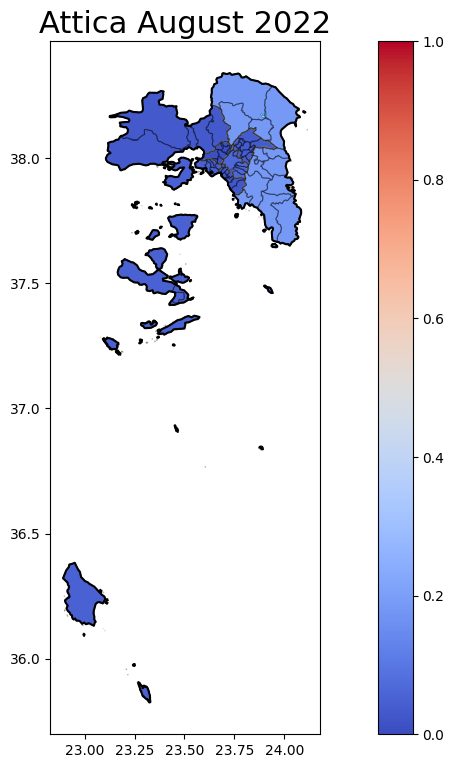

In [25]:
fig, ax = plt.subplots(figsize=figure_size)

# Plot the geometry column with the colors based on the float column
results.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)


plt.title(f'{NUTS2} {month_dict.get(results.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

In [26]:
fig = interactive_colored_mapbox(results, greece_lakes, greece_nuts3_gdf, #greece_lau1, 
                                 index_col=None, color_col='risk_score', hover_name='NUTS3_NAME', 
                                 hover_data={'risk_score':True, 'x': True, 'y': True, 'NUTS3_ID': True}, 
                                 center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
                                         'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
                                 zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, fig_title = '[EL30]Attica - August 2022',
                                 index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
                                 hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=650, fig_width=1000, size_f5=6.5)

fig.show()

In [27]:
results

,NUTS3_ID,year,month,x,y,risk_score,NUTS3_NAME,geometry
0,EL301,2022,8,23.8251,38.0560,0.038484,Βόρειος Τομέας Αθηνών,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL302,2022,8,23.6865,38.0249,0.008371,Δυτικός Τομέας Αθηνών,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL303,2022,8,23.7575,37.9735,0.065113,Κεντρικός Τομέας Αθηνών,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL304,2022,8,23.7454,37.9064,0.025840,Νότιος Τομέας Αθηνών,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL305,2022,8,23.8866,38.0406,0.186514,Ανατολική Αττική,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."
5,EL306,2022,8,23.3953,38.0911,0.032766,Δυτική Αττική,"MULTIPOLYGON (((23.63450 38.21134, 23.63721 38..."
6,EL307,2022,8,23.2188,37.0018,0.049945,"Πειραιάς, Νήσοι","MULTIPOLYGON (((23.93391 37.47779, 23.94228 37..."


In [28]:
results[['NUTS3_ID', 'NUTS3_NAME', 'year', 'month', 'risk_score']]

,NUTS3_ID,NUTS3_NAME,year,month,risk_score
0,EL301,Βόρειος Τομέας Αθηνών,2022,8,0.038484
1,EL302,Δυτικός Τομέας Αθηνών,2022,8,0.008371
2,EL303,Κεντρικός Τομέας Αθηνών,2022,8,0.065113
3,EL304,Νότιος Τομέας Αθηνών,2022,8,0.025840
4,EL305,Ανατολική Αττική,2022,8,0.186514
5,EL306,Δυτική Αττική,2022,8,0.032766
6,EL307,"Πειραιάς, Νήσοι",2022,8,0.049945


In [29]:
#results.to_file(f'../../../data/{NUTS2}/predictions/GR_{NUTS2}_NUTS3_Predictions_June_2024.shp', encoding = 'utf-8')